# Normal-Only Anomaly Detection

Normal-only anomaly detection is viable, but it is easy to oversell.

The valid use case is: real defects are rare or unavailable during training, so we train only on clean examples and flag samples that do not look normal. This is common in industrial inspection, cybersecurity, machine monitoring, and scientific discovery.

The false direction is: train a QNN only on clean labels and expect it to learn defects. A classifier needs contrast. This notebook therefore tests two normal-only strategies:

1. Pure one-class detectors trained only on clean data.
2. A self-supervised QCNN trained on clean data plus synthetic corruptions generated from clean data, with no real defect labels.

## 1. Imports

This notebook reports anomaly metrics where label `1` means anomaly/defect.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM, SVC

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit.quantum_info import SparsePauliOp, Statevector
from qiskit_algorithms.optimizers import COBYLA
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.algorithms.classifiers import NeuralNetworkClassifier
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.neural_networks import SamplerQNN

SEED = 8398
np.random.seed(SEED)

## 2. Helpers

The held-out anomalies are used only for final evaluation. The self-supervised QNN sees normal samples and fake corruptions generated from normal samples.

In [2]:
def coupled_texture_score(X):
    """Hidden coupled texture score used to build proxy defects."""
    return (
        np.sin(X[:, 0]) * np.cos(X[:, 1])
        + np.sin(X[:, 2] + X[:, 3])
        + 0.25 * np.cos(X[:, 0] - X[:, 2])
    )


def latents_to_microtexture_images(X, size=8, seed=SEED):
    """Render four compact texture factors as small grayscale inspection patches."""
    rng = np.random.default_rng(seed)
    grid = np.linspace(0, 2 * np.pi, size)
    rr, cc = np.meshgrid(grid, grid, indexing="ij")
    images = []

    for x in X:
        img = (
            0.50
            + 0.16 * np.sin(rr + x[0])
            + 0.13 * np.cos(cc + x[1])
            + 0.10 * np.sin(rr + cc + x[2])
            + 0.08 * np.cos(rr - cc + x[3])
        )
        img += rng.normal(0.0, 0.025, size=(size, size))
        images.append(np.clip(img, 0.0, 1.0))

    return np.array(images)


def show_microtextures(images, labels, scores=None, n_show=12, cols=6):
    order = np.arange(min(n_show, len(images)))
    rows = int(np.ceil(len(order) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.7))
    axes = np.ravel(axes)

    for ax, idx in zip(axes, order):
        ax.imshow(images[idx], cmap="gray_r", vmin=0, vmax=1)
        label = "DEFECT" if labels[idx] else "clean"
        suffix = "" if scores is None else f"\nscore={scores[idx]:.2f}"
        ax.set_title(f"#{idx} {label}{suffix}", fontsize=8, color="crimson" if labels[idx] else "black")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(order):]:
        ax.axis("off")

    fig.tight_layout()
    plt.show()


def evaluate_predictions(name, y_true, y_pred, scores=None, *, show_confusion=True):
    """Report rare-defect metrics. Label 1 is defect/anomaly."""
    print(f"\n{name}")
    print("ordinary accuracy:", accuracy_score(y_true, y_pred))
    print("balanced accuracy:", balanced_accuracy_score(y_true, y_pred))
    print("defect/anomaly F1:", f1_score(y_true, y_pred, zero_division=0))
    print("defect recall   :", ((y_pred == 1) & (y_true == 1)).sum() / max(1, (y_true == 1).sum()))
    print("false alarm rate:", ((y_pred == 1) & (y_true == 0)).sum() / max(1, (y_true == 0).sum()))
    if scores is not None:
        print("average precision:", average_precision_score(y_true, scores))
        try:
            print("ROC AUC          :", roc_auc_score(y_true, scores))
        except ValueError:
            pass
    print(classification_report(y_true, y_pred, target_names=["clean", "defect"], zero_division=0))

    if show_confusion:
        ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["clean", "defect"])
        plt.title(name)
        plt.show()


def evaluate_classifier(name, model, X_eval, y_eval, *, show_confusion=False):
    pred = model.predict(X_eval)
    scores = None
    if hasattr(model, "predict_proba"):
        try:
            scores = model.predict_proba(X_eval)[:, 1]
        except Exception:
            scores = None
    elif hasattr(model, "decision_function"):
        try:
            scores = model.decision_function(X_eval)
        except Exception:
            scores = None
    evaluate_predictions(name, y_eval, pred, scores=scores, show_confusion=show_confusion)
    return pred


def balanced_subset(X_data, y_data, n_clean_per_defect=3, seed=SEED):
    """Use every rare defect and a controlled number of clean examples."""
    rng = np.random.default_rng(seed)
    defect_idx = np.flatnonzero(y_data == 1)
    clean_idx = np.flatnonzero(y_data == 0)
    n_clean = min(len(clean_idx), max(1, len(defect_idx) * n_clean_per_defect))
    chosen = defect_idx.tolist() + rng.choice(clean_idx, size=n_clean, replace=False).tolist()
    rng.shuffle(chosen)
    return X_data[chosen], y_data[chosen]


def build_qcnn_style_circuit(n_qubits=4):
    """Compact QCNN-style QNN for four texture features."""
    x = ParameterVector("x", n_qubits)
    theta = ParameterVector("theta", 10)
    qc = QuantumCircuit(n_qubits)

    for q in range(n_qubits):
        qc.ry(x[q], q)

    qc.cx(0, 1)
    qc.ry(theta[0], 1)
    qc.rz(theta[1], 0)
    qc.cx(1, 0)
    qc.ry(theta[2], 0)

    qc.cx(2, 3)
    qc.ry(theta[0], 3)
    qc.rz(theta[1], 2)
    qc.cx(3, 2)
    qc.ry(theta[2], 2)

    qc.cx(1, 0)
    qc.ry(theta[3], 0)
    qc.cz(1, 0)
    qc.cx(3, 2)
    qc.ry(theta[4], 2)
    qc.cz(3, 2)

    qc.cx(0, 2)
    qc.ry(theta[5], 2)
    qc.rz(theta[6], 0)
    qc.cx(2, 0)
    qc.ry(theta[7], 0)
    qc.ry(theta[8], 2)
    qc.cz(0, 2)
    qc.ry(theta[9], 0)

    return qc, list(x), list(theta)


def readout_q0(measured_integer):
    return measured_integer & 1



def sample_normal_features(n_samples, rng, noise=0.12):
    """Normal-only texture manifold."""
    t = rng.uniform(0.0, 2 * np.pi, n_samples)
    u = rng.uniform(0.0, 2 * np.pi, n_samples)
    return np.column_stack([
        t,
        u,
        (t + u + rng.normal(0.0, noise, n_samples)) % (2 * np.pi),
        (t - u + rng.normal(0.0, noise, n_samples)) % (2 * np.pi),
    ])


def sample_true_anomalies(n_samples, rng):
    """Held-out defects/anomalies. These are not used for training."""
    X = sample_normal_features(n_samples, rng)
    modes = rng.integers(0, 4, size=n_samples)
    for i, mode in enumerate(modes):
        if mode == 0:
            X[i, 2] = rng.uniform(0.0, 2 * np.pi)
        elif mode == 1:
            X[i, 3] = rng.uniform(0.0, 2 * np.pi)
        elif mode == 2:
            X[i, 2] = (X[i, 2] + rng.uniform(1.5, 3.0)) % (2 * np.pi)
        else:
            X[i] = rng.uniform(0.0, 2 * np.pi, 4)
    return X


def make_pseudo_anomalies_from_normal(X_normal, seed=SEED):
    """Self-supervised corruptions made only from normal training data."""
    rng = np.random.default_rng(seed)
    X_fake = X_normal.copy()

    for i in range(len(X_fake)):
        mode = rng.integers(0, 4)
        if mode == 0:
            X_fake[i, 2] = rng.choice(X_normal[:, 2])
        elif mode == 1:
            X_fake[i, 3] = rng.choice(X_normal[:, 3])
        elif mode == 2:
            X_fake[i, [2, 3]] = rng.uniform(0.0, 2 * np.pi, 2)
        else:
            X_fake[i] = (X_fake[i] + rng.normal(0.0, 1.5, 4)) % (2 * np.pi)

    return X_fake


def anomaly_metrics_from_scores(name, normal_val_scores, test_scores, y_test, false_alarm_quantile=0.95):
    """Set threshold from normal-only validation scores and evaluate on mixed test data."""
    threshold = np.quantile(normal_val_scores, false_alarm_quantile)
    pred = (test_scores >= threshold).astype(int)
    print("threshold from normal validation:", threshold)
    evaluate_predictions(name, y_test, pred, scores=test_scores, show_confusion=False)
    return pred, threshold


def build_projected_quantum_features(X_data, feature_map):
    """Local projected quantum features for one-class classical detectors."""
    params = list(feature_map.parameters)
    observables = []
    for pauli in ["X", "Y", "Z"]:
        for i in range(4):
            observables.append(SparsePauliOp.from_sparse_list([(pauli, [i], 1.0)], num_qubits=4))
    for pauli in ["XX", "YY", "ZZ"]:
        for i in range(4):
            for j in range(i + 1, 4):
                observables.append(SparsePauliOp.from_sparse_list([(pauli, [i, j], 1.0)], num_qubits=4))

    rows = []
    for x in X_data:
        state = Statevector.from_instruction(feature_map.assign_parameters(dict(zip(params, x)), inplace=False))
        rows.append([float(np.real(state.expectation_value(obs))) for obs in observables])
    return np.array(rows)

## 3. Build a Normal-Only Training Setup

Training and validation contain only clean data. The mixed test set contains clean samples and held-out true anomalies.

normal train: (100, 4)
normal val  : (40, 4)
mixed test  : (90, 4) normal: 60 anomaly: 30


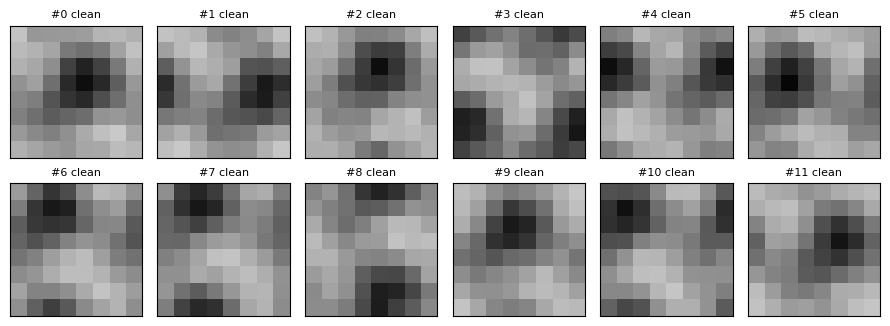

In [3]:
rng = np.random.default_rng(SEED + 600)

X_normal_train = sample_normal_features(100, rng)
X_normal_val = sample_normal_features(40, rng)
X_test_normal = sample_normal_features(60, rng)
X_test_anomaly = sample_true_anomalies(30, rng)

X_test = np.vstack([X_test_normal, X_test_anomaly])
y_test = np.concatenate([
    np.zeros(len(X_test_normal), dtype=int),
    np.ones(len(X_test_anomaly), dtype=int),
])

train_images = latents_to_microtexture_images(X_normal_train[:12], size=8, seed=SEED)
test_images = latents_to_microtexture_images(X_test[:12], size=8, seed=SEED + 1)

print("normal train:", X_normal_train.shape)
print("normal val  :", X_normal_val.shape)
print("mixed test  :", X_test.shape, "normal:", int((y_test == 0).sum()), "anomaly:", int((y_test == 1).sum()))
show_microtextures(test_images, y_test[:12], scores=None, n_show=12, cols=6)

## 4. Classical One-Class Baselines

These are honest normal-only baselines. The threshold is set using only clean validation data.

In [4]:
scaler = StandardScaler().fit(X_normal_train)
Xn = scaler.transform(X_normal_train)
Xv = scaler.transform(X_normal_val)
Xt = scaler.transform(X_test)

one_class_svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
one_class_svm.fit(Xn)
svm_val_scores = -one_class_svm.decision_function(Xv)
svm_test_scores = -one_class_svm.decision_function(Xt)
anomaly_metrics_from_scores("Raw-feature OneClassSVM", svm_val_scores, svm_test_scores, y_test)

isolation_forest = IsolationForest(contamination=0.05, random_state=SEED)
isolation_forest.fit(Xn)
if_val_scores = -isolation_forest.decision_function(Xv)
if_test_scores = -isolation_forest.decision_function(Xt)
anomaly_metrics_from_scores("Raw-feature IsolationForest", if_val_scores, if_test_scores, y_test)

threshold from normal validation: 0.07505070212152305

Raw-feature OneClassSVM
ordinary accuracy: 0.7
balanced accuracy: 0.6
defect/anomaly F1: 0.4
defect recall   : 0.3
false alarm rate: 0.1
average precision: 0.4490284735440417
ROC AUC          : 0.4872222222222222
              precision    recall  f1-score   support

       clean       0.72      0.90      0.80        60
      defect       0.60      0.30      0.40        30

    accuracy                           0.70        90
   macro avg       0.66      0.60      0.60        90
weighted avg       0.68      0.70      0.67        90

threshold from normal validation: 0.002117084659767189

Raw-feature IsolationForest
ordinary accuracy: 0.6222222222222222
balanced accuracy: 0.5
defect/anomaly F1: 0.19047619047619047
defect recall   : 0.13333333333333333
false alarm rate: 0.13333333333333333
average precision: 0.3544288284709206
ROC AUC          : 0.5183333333333333
              precision    recall  f1-score   support

       clean  

(array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0]),
 np.float64(0.002117084659767189))

## 5. Projected Quantum Features for One-Class Detection

This is a quantum-feature version of normal-only detection: encode the sample into a quantum feature map, measure local Pauli observables, then train a one-class detector on clean projected features.

In [5]:
feature_map = zz_feature_map(feature_dimension=4, reps=1)

F_normal_train = build_projected_quantum_features(X_normal_train, feature_map)
F_normal_val = build_projected_quantum_features(X_normal_val, feature_map)
F_test = build_projected_quantum_features(X_test, feature_map)

proj_scaler = StandardScaler().fit(F_normal_train)
Fn = proj_scaler.transform(F_normal_train)
Fv = proj_scaler.transform(F_normal_val)
Ft = proj_scaler.transform(F_test)

projected_svm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
projected_svm.fit(Fn)
proj_val_scores = -projected_svm.decision_function(Fv)
proj_test_scores = -projected_svm.decision_function(Ft)
anomaly_metrics_from_scores("Projected-quantum OneClassSVM", proj_val_scores, proj_test_scores, y_test)

threshold from normal validation: 0.16857358526085875

Projected-quantum OneClassSVM
ordinary accuracy: 0.6333333333333333
balanced accuracy: 0.48333333333333334
defect/anomaly F1: 0.05714285714285714
defect recall   : 0.03333333333333333
false alarm rate: 0.06666666666666667
average precision: 0.36972142091527904
ROC AUC          : 0.5650000000000001
              precision    recall  f1-score   support

       clean       0.66      0.93      0.77        60
      defect       0.20      0.03      0.06        30

    accuracy                           0.63        90
   macro avg       0.43      0.48      0.41        90
weighted avg       0.51      0.63      0.53        90



(array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1]),
 np.float64(0.16857358526085875))

## 6. Self-Supervised QCNN From Normal Data Only

A pure classifier cannot learn anomalies if every training label is clean. A practical compromise is to generate fake corruptions from clean data and train the QNN to detect broken normal structure. No true defect labels are used.

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.



Self-supervised QCNN anomaly detector
ordinary accuracy: 0.5666666666666667
balanced accuracy: 0.5666666666666667
defect/anomaly F1: 0.4657534246575342
defect recall   : 0.5666666666666667
false alarm rate: 0.43333333333333335
average precision: 0.3834021237318144
ROC AUC          : 0.5461111111111111
              precision    recall  f1-score   support

       clean       0.72      0.57      0.64        60
      defect       0.40      0.57      0.47        30

    accuracy                           0.57        90
   macro avg       0.56      0.57      0.55        90
weighted avg       0.61      0.57      0.58        90



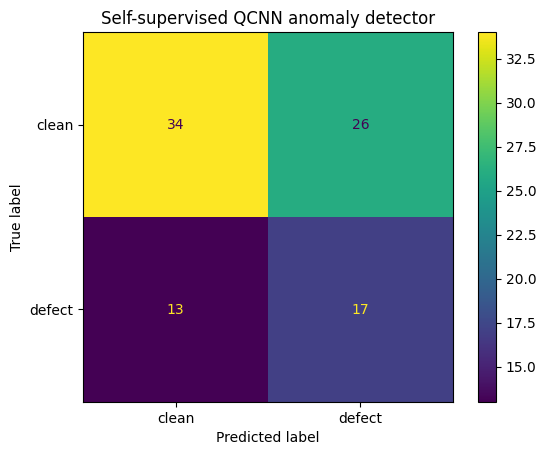

In [6]:
X_fake_anomaly = make_pseudo_anomalies_from_normal(X_normal_train, seed=SEED + 1)
X_ssl_train = np.vstack([X_normal_train, X_fake_anomaly])
y_ssl_train = np.concatenate([
    np.zeros(len(X_normal_train), dtype=int),
    np.ones(len(X_fake_anomaly), dtype=int),
])

# Keep QNN training small and balanced.
rng = np.random.default_rng(SEED)
chosen = []
for cls in [0, 1]:
    cls_idx = np.flatnonzero(y_ssl_train == cls)
    chosen.extend(rng.choice(cls_idx, size=36, replace=False).tolist())
rng.shuffle(chosen)

qcnn_circuit, input_params, weight_params = build_qcnn_style_circuit(n_qubits=4)
sampler_qnn = SamplerQNN(
    circuit=qcnn_circuit,
    sampler=StatevectorSampler(seed=SEED),
    input_params=input_params,
    weight_params=weight_params,
    interpret=readout_q0,
    output_shape=2,
)

qcnn_anomaly_detector = NeuralNetworkClassifier(
    neural_network=sampler_qnn,
    optimizer=COBYLA(maxiter=60),
    initial_point=rng.uniform(-0.2, 0.2, size=len(weight_params)),
)

qcnn_anomaly_detector.fit(X_ssl_train[chosen], y_ssl_train[chosen])
qcnn_pred = qcnn_anomaly_detector.predict(X_test)
qcnn_scores = qcnn_anomaly_detector.predict_proba(X_test)[:, 1]
evaluate_predictions("Self-supervised QCNN anomaly detector", y_test, qcnn_pred, scores=qcnn_scores)

## 7. Takeaway

Normal-only anomaly detection is viable if framed carefully:

- Pure one-class methods are the cleanest scientifically: they train only on normal data and set thresholds from normal validation data.
- A QNN classifier needs contrast, so a defensible QNN version uses self-supervised corruptions made from clean data.
- The claim should be "normal-only or defect-label-scarce anomaly screening," not "we learned defects without any defect signal."

## References and AI Tools Disclosure

This notebook was drafted with OpenAI Codex/GPT-5 assistance in the local hackathon workspace. The team should treat the code and results as AI-assisted prototypes and verify claims before presenting them.

AI-assisted notebooks in this `main_challenge` folder:

- `01_defect_classical_hardness_audit.ipynb`
- `02_quantum_kernel_teacher_defects.ipynb`
- `03_projected_quantum_kernel_features.ipynb`
- `04_qnn_vs_kernel_bakeoff.ipynb`
- `05_qcnn_industrial_microdefects.ipynb`
- `06_data_reuploading_qnn_microdefects.ipynb`
- `07_qnn_kernel_pivot_scoreboard.ipynb`
- `08_imbalanced_rare_defect_qnn.ipynb`
- `09_normal_only_anomaly_detection.ipynb`
- `10_heat_exchanger_network_qubo_qaoa.ipynb`
- `11_Final_QCNN_rare_defect_detection.ipynb`

References used for the quantum-ML and optimization direction:

- Cong, Choi, and Lukin, "Quantum convolutional neural networks," Nature Physics 15, 1273-1278 (2019): https://www.nature.com/articles/s41567-019-0648-8
- Perez-Salinas et al., "Data re-uploading for a universal quantum classifier," Quantum 4, 226 (2020): https://doi.org/10.22331/q-2020-02-06-226 and https://arxiv.org/abs/1907.02085
- McClean et al., "Barren plateaus in quantum neural network training landscapes," Nature Communications 9, 4812 (2018): https://www.nature.com/articles/s41467-018-07090-4
- Havlicek et al., "Supervised learning with quantum-enhanced feature spaces," Nature 567, 209-212 (2019): https://www.nature.com/articles/s41586-019-0980-2
- Scholkopf et al., "Estimating the Support of a High-Dimensional Distribution," Neural Computation 13(7), 1443-1471 (2001): https://doi.org/10.1162/089976601750264965
- Furman and Sahinidis, "Computational complexity of heat exchanger network synthesis," Computers & Chemical Engineering 25(9-10), 1371-1390 (2001): https://doi.org/10.1016/S0098-1354(01)00681-0
- Qiskit Machine Learning `SamplerQNN` documentation: https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html